In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim

from collections import namedtuple
from itertools import count
from torch.distributions import Categorical

from src.utils.Wordle import WordleEnv
from src.models.ActorCritic import Actor, Critic
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))

# Initialize the environment (input subset size if necessary)
env = WordleEnv()

plt.ion()

# if GPU is to be used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print(x)
else:
    print ("MPS device not found.")

torch.set_default_device(device)

MPS device not found.


## Actor Critic

In [4]:
def select_action_actor(actor, state, available_actions, action_size):
    # Create a mask tensor for previously chosen actions
    mask = torch.full((action_size,), -1e9, device=device)
    for idx in available_actions:
        mask[idx] = 0

    # Add the mask to the actor output and sample from the distribution
    actor_output = actor(state)
    masked_output = actor_output + mask
    masked_distribution = Categorical(logits=masked_output)
    return masked_distribution.sample().view(1, 1)
        
def select_word(actor_t):
    """
    Selects a word from the distribution.
    """
    z = torch.randn(1, 8, device=device) # As per PAIRED paper
    teacher_output = actor_t(z)
    distribution = Categorical(logits=teacher_output)
    return env.words[distribution.sample().view(1, 1)]


In [5]:
def run_episode(actor, critic, optimizer_actor, optimizer_critic, state): 
    """
    Runs one episode for the protagonist/antagonist
    """
    log_probs = []
    values = []
    rewards = []
    masks = []
    
    for _ in count():
        actor_output, value = actor(state), critic(state)
        mask = torch.full((env.action_size,), -1e9, device=device)
        for idx in env.available_actions:
            mask[idx] = 0.0

        masked_output = actor_output + mask
        dist = Categorical(logits=masked_output)
        action = dist.sample().view(1, 1)
        next_state, reward, done, _ = env.step(action.item())
        next_state = torch.tensor(next_state, dtype=torch.float32, device=device).unsqueeze(0)
    
        log_prob = dist.log_prob(action).unsqueeze(1)
    
        log_probs.append(log_prob)
        if value.dim() > 1:
            values.append(value.squeeze(0))
        else:
            values.append(value)
        rewards.append(torch.tensor([reward], dtype=torch.float, device=device))
        masks.append(torch.tensor([1-done], dtype=torch.float, device=device))
    
        state = next_state
    
        if done:
            break
    returns = []
    reward = 0

    for r, m in  zip(reversed(rewards), reversed(masks)):
        reward = r + 0.99 * reward * m # Setting gamma to 0.99 for discounted reward
        returns.insert(0, reward)

    returns = torch.cat(returns).detach()
    if values:
        values = torch.cat(values, dim=0).unsqueeze(1)
    else:
        # If values is empty, initialize it with a dummy tensor to avoid errors
        values = torch.zeros(1, 1, device=device, requires_grad=True)    
    log_probs = torch.cat(log_probs)
    

    advantage = returns - values
    
    optimizer_actor.zero_grad()
    optimizer_critic.zero_grad()
    
    actor_loss = -(log_probs * advantage.detach()).mean()
    critic_loss = advantage.pow(2).mean()

    actor_loss.backward()
    critic_loss.backward()
    optimizer_actor.step()
    optimizer_critic.step()

    return returns[env.attempts-1].item(), env.attempts

In [6]:
def plot_performance(rewards_p, rewards_a):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_p, label='Protagonist')
    plt.plot(rewards_a, label='Antagonist')
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.title('Reward per episode')
    plt.legend()

In [7]:
num_episodes = 30000

seeds = range(1)
for seed in seeds:
    np.random.seed(seed)
    torch.manual_seed(seed)
    rewards_p = [0] * num_episodes
    rewards_a = [0] * num_episodes

    # Actor and critic for the protagonist
    actor_p = Actor(env.state_size, env.action_size).to(device)
    critic_p = Critic(env.state_size, env.action_size).to(device)
    optimizer_actor_p = optim.Adam(actor_p.parameters(), lr=0.001)
    optimizer_critic_p = optim.Adam(critic_p.parameters(), lr=0.001)

    # Actor and critic for the antagonist
    actor_a = Actor(env.state_size, env.action_size).to(device)
    critic_a = Critic(env.state_size, env.action_size).to(device)
    optimizer_actor_a = optim.Adam(actor_a.parameters(), lr=0.001)
    optimizer_critic_a = optim.Adam(critic_a.parameters(), lr=0.001)

    # Actor and critic for the teacher
    actor_t = Actor(8, env.action_size).to(device)
    critic_t = Critic(8, env.action_size).to(device)
    optimizer_actor_t = optim.Adam(actor_t.parameters(), lr=0.001)
    optimizer_critic_t = optim.Adam(critic_t.parameters(), lr=0.001)
    for episode in range(num_episodes):
        z = torch.randn(1, 8, device=device) # As per PAIRED paper
        teacher_output = actor_t(z)
        distribution = Categorical(logits=teacher_output)
        teacher_action = distribution.sample().view(1, 1)
        target = env.words[teacher_action]
        log_prob = distribution.log_prob(teacher_action)

        state = env.reset()
        env.target_word = target
        state = torch.FloatTensor(state).to(device)
        reward_p, attempts_p = run_episode(actor_p, critic_p, optimizer_actor_p, optimizer_critic_p, state=state)
        rewards_p[episode] = reward_p

        state = env.reset()
        env.target_word = target
        state = torch.FloatTensor(state).to(device)
        reward_a, attempts_a = run_episode(actor_a, critic_a, optimizer_actor_a, optimizer_critic_a, state=state)
        rewards_a[episode] = reward_a
        if episode%1000:
            print(f"Episode: {episode+1}/{num_episodes}, Protagonist: {reward_p:.2f}, Antagonist: {reward_a:.2f}")
        regret = reward_a - reward_p
        value = critic_t(z)
        advantage = regret - value
        optimizer_actor_t.zero_grad()
        optimizer_critic_t.zero_grad()

        actor_t_loss = -(log_prob * advantage.detach())
        critic_t_loss = advantage.pow(2)

        actor_t_loss.backward()
        critic_t_loss.backward()

        optimizer_actor_t.step()
        optimizer_critic_t.step()

Episode: 2/30000, Protagonist: -10.00, Antagonist: 20.00
Episode: 3/30000, Protagonist: 20.00, Antagonist: 20.00
Episode: 4/30000, Protagonist: 30.00, Antagonist: 20.00
Episode: 5/30000, Protagonist: 30.00, Antagonist: 20.00
Episode: 6/30000, Protagonist: 30.00, Antagonist: 40.00
Episode: 7/30000, Protagonist: 20.00, Antagonist: 10.00
Episode: 8/30000, Protagonist: 30.00, Antagonist: 40.00
Episode: 9/30000, Protagonist: 20.00, Antagonist: -10.00
Episode: 10/30000, Protagonist: 30.00, Antagonist: 40.00
Episode: 11/30000, Protagonist: 30.00, Antagonist: 30.00
Episode: 12/30000, Protagonist: -10.00, Antagonist: -10.00
Episode: 13/30000, Protagonist: 10.00, Antagonist: 30.00
Episode: 14/30000, Protagonist: -10.00, Antagonist: -10.00
Episode: 15/30000, Protagonist: 20.00, Antagonist: -10.00
Episode: 16/30000, Protagonist: -10.00, Antagonist: -10.00
Episode: 17/30000, Protagonist: 30.00, Antagonist: -10.00
Episode: 18/30000, Protagonist: 30.00, Antagonist: 30.00
Episode: 19/30000, Protagonis

KeyboardInterrupt: 

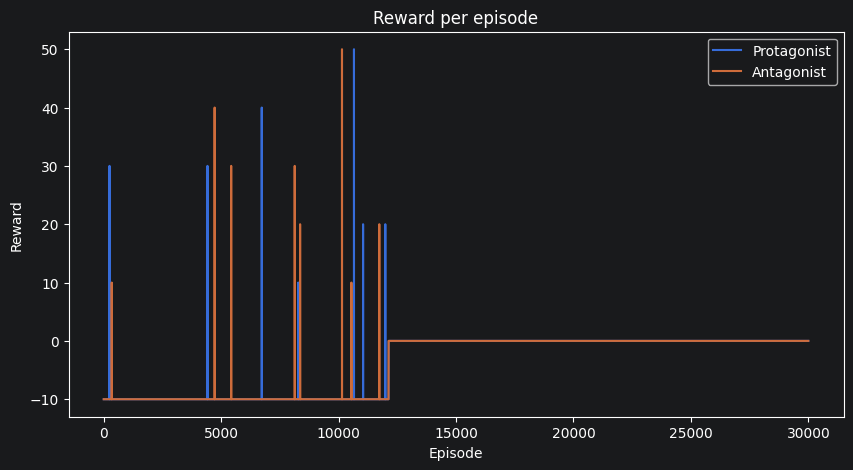

In [22]:
plot_performance(rewards_p, rewards_a)

In [ ]:
total_attempts = 0
correct_guesses = 0

no_test_trials = 30000

eps_threshold = 1e-11 #For only exploration

for episode in range(no_test_trials):
    state = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

    for t in count():
        action = select_action_actor(actor_p, state, env.available_actions, env.action_size)
        observation, reward, done, _ = env.step(action.item())
        reward = torch.tensor([reward], device=device)
        
        if done:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

        state = next_state
        total_attempts += 1

        if done:
            if reward[0] == 10:
                correct_guesses += 1
            break

success_rate = correct_guesses / no_test_trials
average_attempts = total_attempts / no_test_trials

print(f"Trials: {no_test_trials}, Success rate: {success_rate:.2f}, Average number of attempts: {average_attempts:.2f}")

In [ ]:
total_attempts = 0
correct_guesses = 0

no_test_trials = 30000

eps_threshold = 1e-11 #For only exploration

for episode in range(no_test_trials):
    state = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    
    action = torch.tensor([[345]], device=device, dtype=torch.long) #Salet start.
    for t in count():
        observation, reward, done, _ = env.step(action.item())
        reward = torch.tensor([reward], device=device)
        
        if done:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

        state = next_state
        total_attempts += 1

        if done:
            if reward[0] == 10:
                correct_guesses += 1
            break
        action = select_action_actor(actor_p, state, env.available_actions, env.action_size)

success_rate = correct_guesses / no_test_trials
average_attempts = total_attempts / no_test_trials

print(f"Trials with SALET start: {no_test_trials}, Success rate: {success_rate:.2f}, Average number of attempts: {average_attempts:.2f}")

In [ ]:
state = env.reset()
env.target_word = 'OTHER'
state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
action = torch.tensor([[344]], device=device, dtype=torch.long) #Salet start.

for t in count():
    observation, reward, done, _ = env.step(action.item())
    reward = torch.tensor([reward], device=device)
    env.render()
    if done:
        next_state = None
    else:
        next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
        
    if done:
        break
    action = select_action_actor(actor_p, state, env.available_actions, env.action_size)
    state = next_state

# CL part

In [ ]:
# Same as before but added variables to plot results

def run_episode_cl(actor, critic, optimizer_actor, optimizer_critic, state, env):
    log_probs = []
    values = []
    rewards = []
    masks = []
    episode_won = False
    
    for i in count():
        actor_output, value = actor(state), critic(state)
        mask = torch.full((env.action_size,), -1e9, device=device)
        for idx in env.available_actions:
            mask[idx] = 0.0

        masked_output = actor_output + mask
        dist = Categorical(logits=masked_output)
        action = dist.sample().view(1, 1)
        
        # next_state, reward, done, _ = env.step(action.item())

        next_state, reward, done, info = env.step(action.item())
        
        # Verifying if the game is won already
        if info.get("won", False):
            episode_won = True
        
        next_state = torch.tensor(next_state, dtype=torch.float32, device=device).unsqueeze(0)
    
        log_prob = dist.log_prob(action).unsqueeze(1)
    
        log_probs.append(log_prob)
        if value.dim() > 1:
            values.append(value.squeeze(0))
        else:
            values.append(value)
            
        rewards.append(torch.tensor([reward], dtype=torch.float, device=device))
        masks.append(torch.tensor([1-done], dtype=torch.float, device=device))
    
        state = next_state
    
        if done:
            break

    # --- Actor-Critic Update ---
    returns = []
    discounted_reward = 0

    # Calculate discounted rewards
    for r, m in zip(reversed(rewards), reversed(masks)):
        discounted_reward = r + 0.99 * discounted_reward * m
        returns.insert(0, discounted_reward)

    returns = torch.cat(returns).detach()
    if values:
        values = torch.cat(values, dim=0).unsqueeze(1)
    else:
        values = torch.zeros(1, 1, device=device, requires_grad=True)    
        
    log_probs = torch.cat(log_probs)
    advantage = returns - values
    
    optimizer_actor.zero_grad()
    optimizer_critic.zero_grad()
    
    actor_loss = -(log_probs * advantage.detach()).mean()
    critic_loss = advantage.pow(2).mean()

    actor_loss.backward()
    critic_loss.backward()
    
    optimizer_actor.step()
    optimizer_critic.step()

    # return final_reward, env.attempts
    return returns[0].item(), env.attempts, episode_won

In [ ]:
import numpy as np
from src.utils.Wordle import WordleEnv

# List of datasets in increasing order of difficulty
curriculum_datasets = [
    # "data/subset_1_easy_479.txt",
    # "data/subset_2_medium_479.txt",
    # "data/subset_3_hard_479.txt"
    "src/data/dataset_1_easy.txt",
    "src/data/dataset_2_medium.txt",
    "src/data/dataset_3_hard.txt"
    
]

episodes_per_phase = 10000 # We should update here after deciding the global number of episodes
# Note that episodes_per_phase = total_episodes/3

# Data for plots
episode_durations = []
episode_rewards = []
win_rate_history = []

# Instantiate a temporary environment just to get the correct dimensions
temp_env = WordleEnv(target_dataset_path=curriculum_datasets[0])
actor = Actor(temp_env.state_size, temp_env.action_size).to(device)
critic = Critic(temp_env.state_size, temp_env.action_size).to(device)

optimizer_actor = optim.Adam(actor.parameters(), lr=0.001)
optimizer_critic = optim.Adam(critic.parameters(), lr=0.001)

for phase_idx, dataset_path in enumerate(curriculum_datasets):
    print(f"\n{'='*50}")
    print(f"--- STARTING PHASE WITH: {dataset_path} ---")
    print(f"{'='*50}")
    
    # Load the actual subset
    env = WordleEnv(target_dataset_path=dataset_path)
    wins = 0
    
    for episode in range(episodes_per_phase):
        state = env.reset()
        state = torch.FloatTensor(state).to(device)
        
        # final_reward, attempts = run_episode_CL(actor, critic, optimizer_actor, optimizer_critic, state, env)
        
        # episode_rewards.append(final_reward)
        # episode_durations.append(attempts)
        
        # if final_reward == 10:
        #     wins += 1

        # NEW :
        final_reward, attempts, episode_won = run_episode_cl(actor, critic, optimizer_actor, optimizer_critic, state, env)
        
        episode_rewards.append(final_reward)
        episode_durations.append(attempts)
        
        if episode_won:
            wins += 1
        
        # Display and save the win rate every 1000 episodes
        if (episode + 1) % 1000 == 0:
            current_win_rate = wins / 1000
            win_rate_history.append(current_win_rate)
            print(f"Episode: {episode + 1}/{episodes_per_phase}, Attempts: {attempts}, Reward: {final_reward:.1f}, Win Rate: {current_win_rate:.2%}")
            wins = 0 

print("\nCurriculum Learning Training Complete!")

In [ ]:
# Plots

def plot_res(durations, rewards, win_rates, filename="Charts/new_charts_CL_subsets.png"):
    plt.figure(figsize=(15, 5))
    
    # Chart 1: Win rate
    plt.subplot(1, 3, 1)
    plt.plot(range(1000, (len(win_rates)+1)*1000, 1000), win_rates, color='green', marker='o')
    plt.title('Win rate (per blocks of 1000)')
    plt.xlabel('Global Episode')
    plt.ylabel('Win Rate')
    plt.grid(True)

    # Chart 2: Sliding average of attempts
    plt.subplot(1, 3, 2)
    if len(durations) > 100:
        means = [np.mean(durations[i:i+100]) for i in range(len(durations)-100)]
        plt.plot(means)
    else:
        plt.plot(durations)
    plt.title("Average attempts (Smoothed over 100 ep)")
    plt.xlabel('Global Episode')
    plt.ylabel("Number of attempts")

    # Chart 3: Reward evolution
    plt.subplot(1, 3, 3)
    if len(rewards) > 100:
        reward_means = [np.mean(rewards[i:i+100]) for i in range(len(rewards)-100)]
        plt.plot(reward_means, color='orange')
    else:
        plt.plot(rewards, color='orange')
    plt.title('Average reward (Smoothed)')
    plt.xlabel('Global Episode')
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Chart successfully saved as: {filename}")
    plt.show()

plot_res(episode_durations, episode_rewards, win_rate_history)

In [ ]:
# Evaluation test as before

def select_best_action(actor, state, available_actions, action_size):
    """ Selects action deterministically (argmax) for evaluation """
    with torch.no_grad():
        mask = torch.full((1, action_size), -1e9, device=device)
        for idx in available_actions:
            mask[0, idx] = 0.0

        actor_output = actor(state)
        masked_output = actor_output + mask
        
        return masked_output.max(1)[1].view(1, 1)

total_attempts = 0
correct_guesses = 0
no_test_trials = 1000

# Test on the hardest dataset (last in the list)
env = WordleEnv(target_dataset_path=curriculum_datasets[-1])

for episode in range(no_test_trials):
    state = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    
    # Depends on the index associate with the word we can to test.
    # I take 345 = LOGON here
    action = torch.tensor([[345]], device=device, dtype=torch.long) 
    
    for t in count():
        observation, reward, done, _ = env.step(action.item())
        
        if done:
            if reward == 10:
                correct_guesses += 1
            total_attempts += env.attempts
            break
            
        next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
        state = next_state
        action = select_best_action(actor, state, env.available_actions, env.action_size)

success_rate = correct_guesses / no_test_trials
average_attempts = total_attempts / no_test_trials

print(f"Validation tests with SALET start: {no_test_trials}")
print(f"Success rate: {success_rate:.2%}")
print(f"Average number of attempts: {average_attempts:.2f}")